# Предобработка данных

In [277]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

training_set = pd.read_csv('data/titanic.csv')

In [278]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [279]:
training_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [280]:
training_set.describe(include=['O'])

C:\Users\vadve\AppData\Local\Temp\ipykernel_44684\2198228790.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  training_set.describe(include=['O'])


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


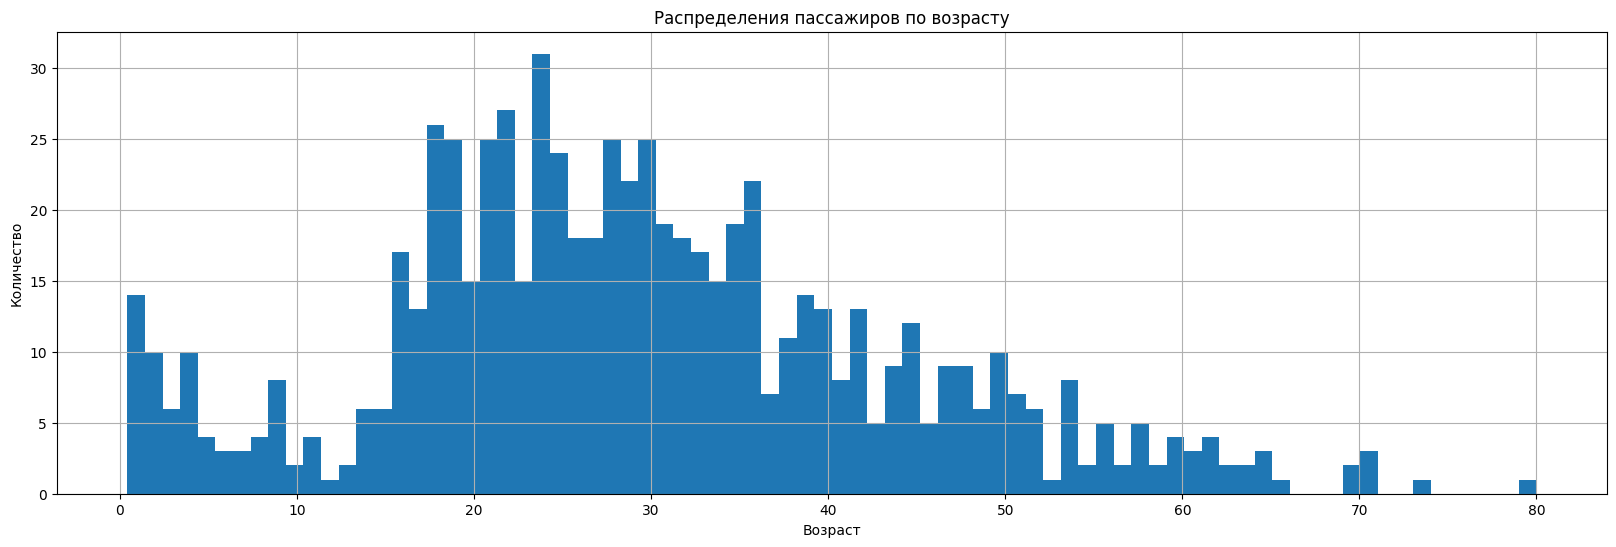

In [281]:
def custom_hist(training_set, title,  xlabel, ylabel='Количество', bins=None):
    figsize = (20,6)
    plt.figure(figsize=figsize)
    plt.grid(True)
    plt.title(title)
    plt.hist(training_set, training_set.max().astype(int) if bins is None else bins)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()
    
custom_hist(training_set["Age"], 'Распределения пассажиров по возрасту', 'Возраст')

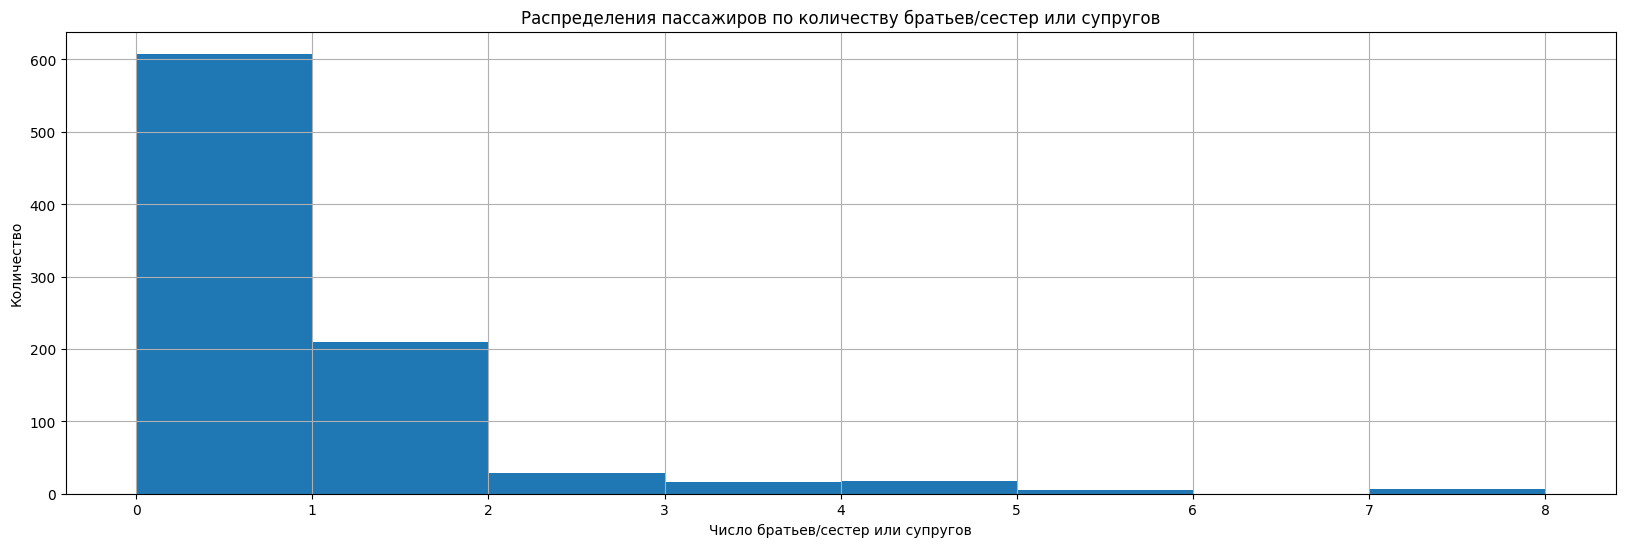

In [282]:
custom_hist(training_set["SibSp"], 'Распределения пассажиров по количеству братьев/сестер или супругов', 
  'Число братьев/сестер или супругов')

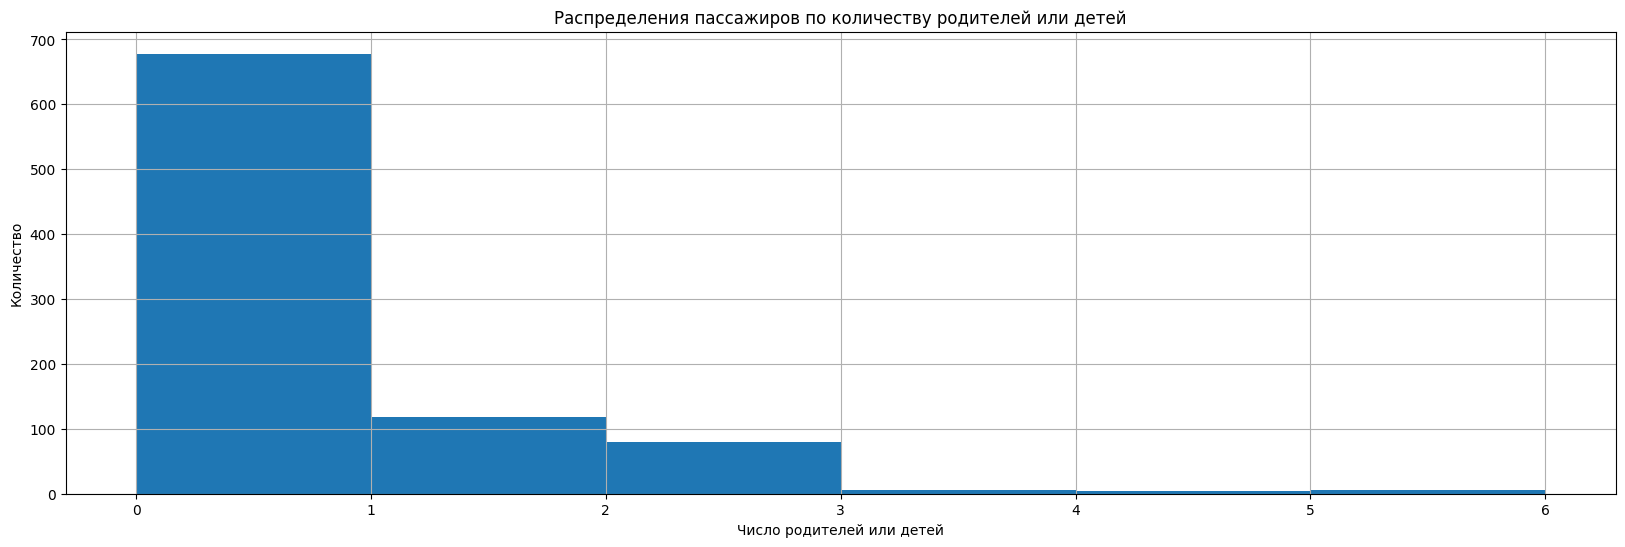

In [283]:
custom_hist(training_set["Parch"], 'Распределения пассажиров по количеству родителей или детей', 
  'Число родителей или детей')

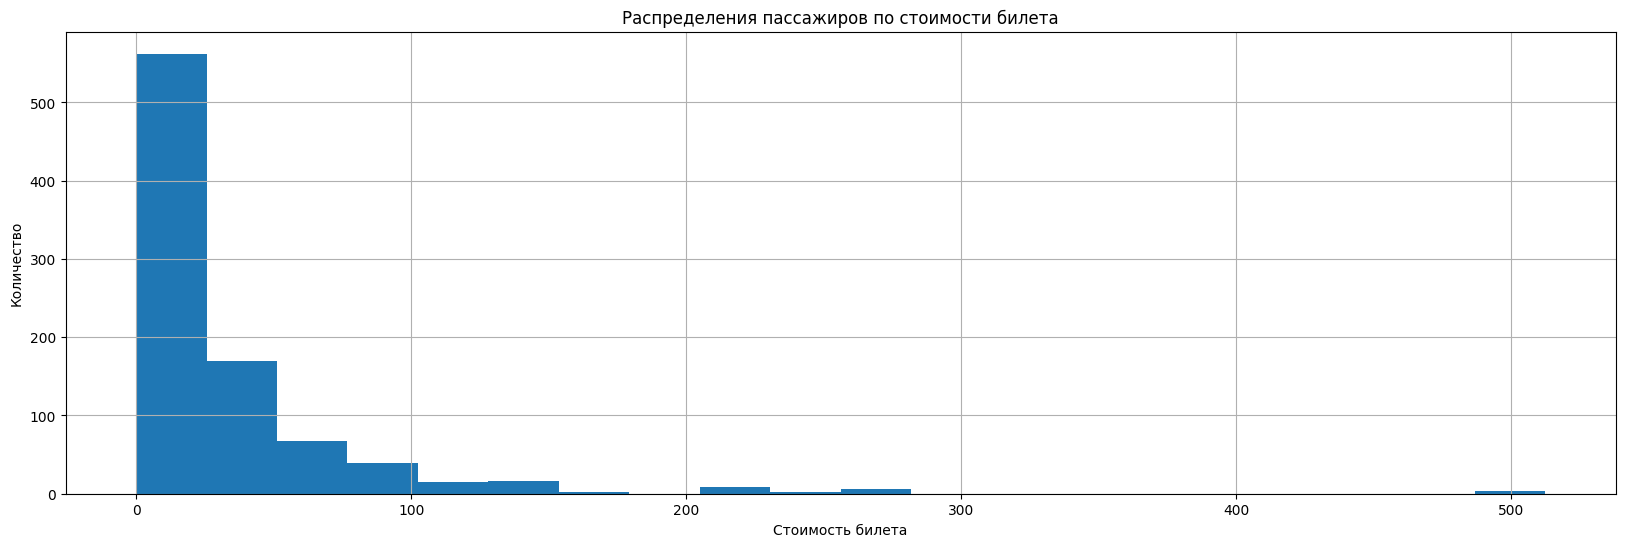

In [284]:
custom_hist(training_set["Fare"], 'Распределения пассажиров по стоимости билета', 
  'Стоимость билета', bins=20)

<Axes: ylabel='Frequency'>

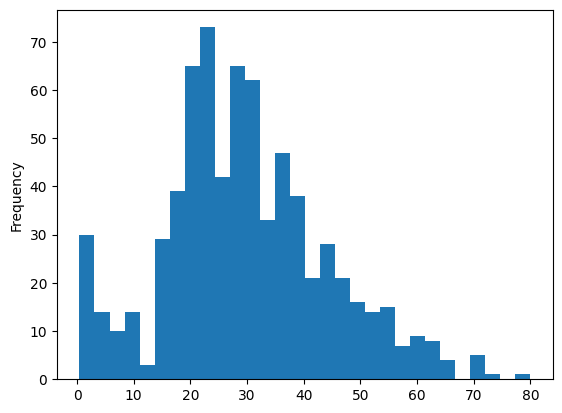

In [285]:
training_set['Age'].plot.hist(bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

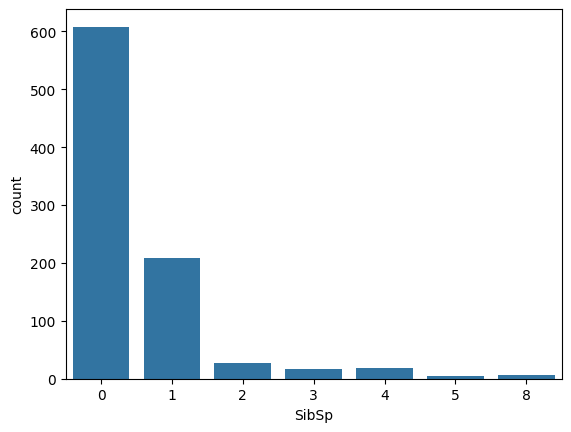

In [286]:
sns.countplot(x='SibSp', data=training_set)

In [287]:
training_set['Fare']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

<Axes: >

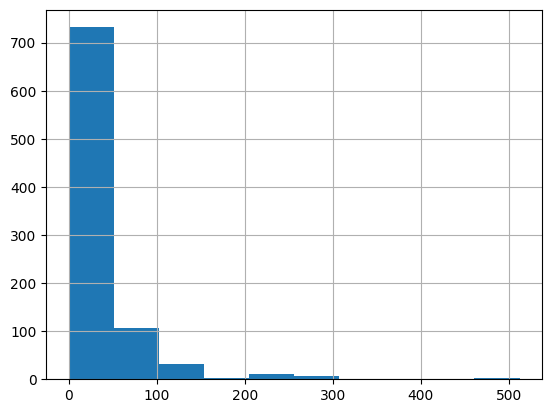

In [288]:
training_set['Fare'].hist()

<Axes: >

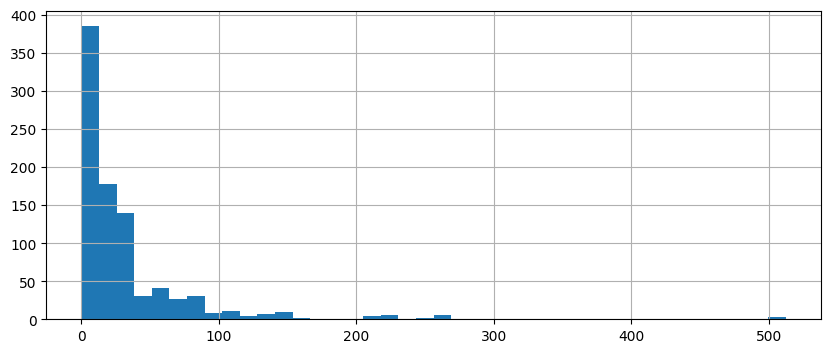

In [289]:
training_set['Fare'].hist(bins=40, figsize=(10,4))

<Axes: xlabel='Survived', ylabel='count'>

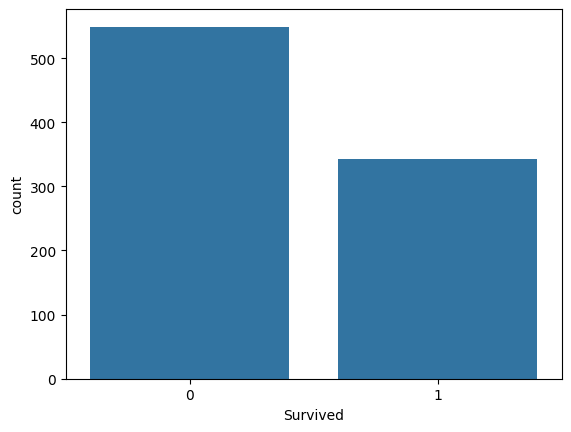

In [290]:
sns.countplot(x='Survived', data=training_set)

<Axes: xlabel='Survived', ylabel='count'>

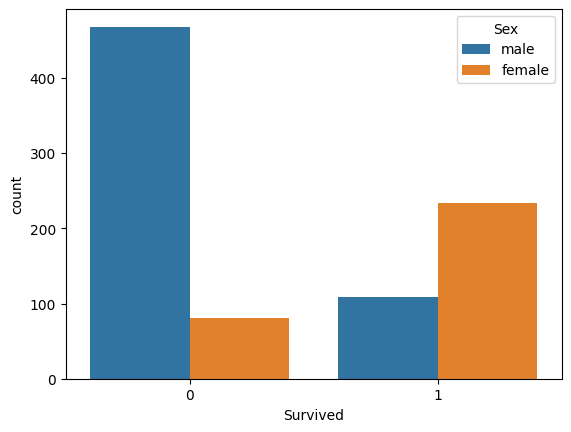

In [291]:
sns.countplot(x='Survived', data=training_set, hue='Sex')

<Axes: xlabel='Survived', ylabel='count'>

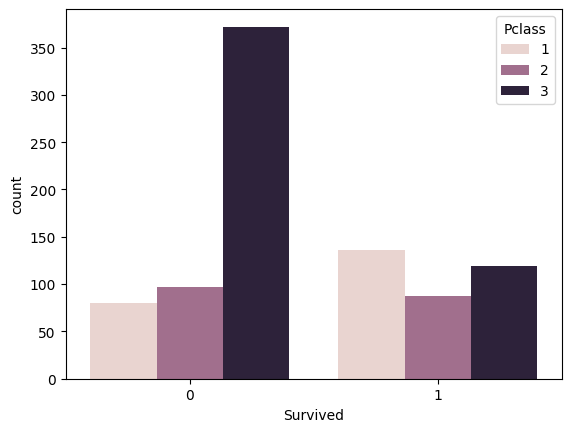

In [292]:
sns.countplot(x='Survived', data=training_set, hue='Pclass')

<Axes: xlabel='Pclass', ylabel='Age'>

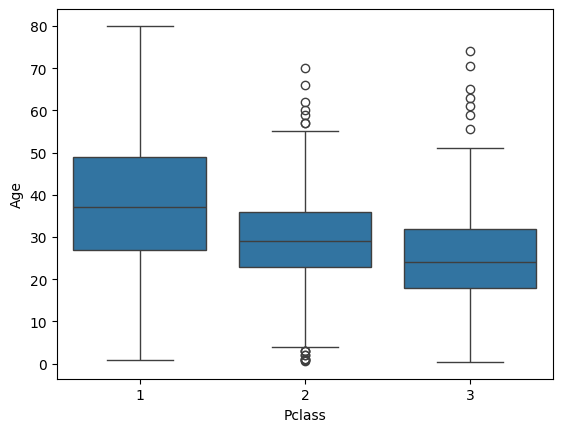

In [293]:
sns.boxplot(x='Pclass', y='Age', data=training_set)

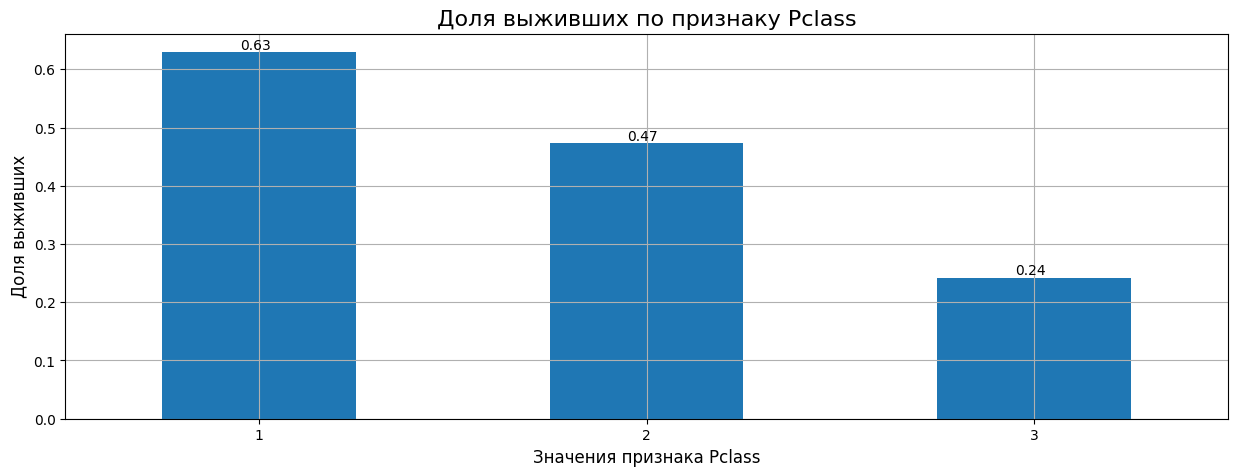

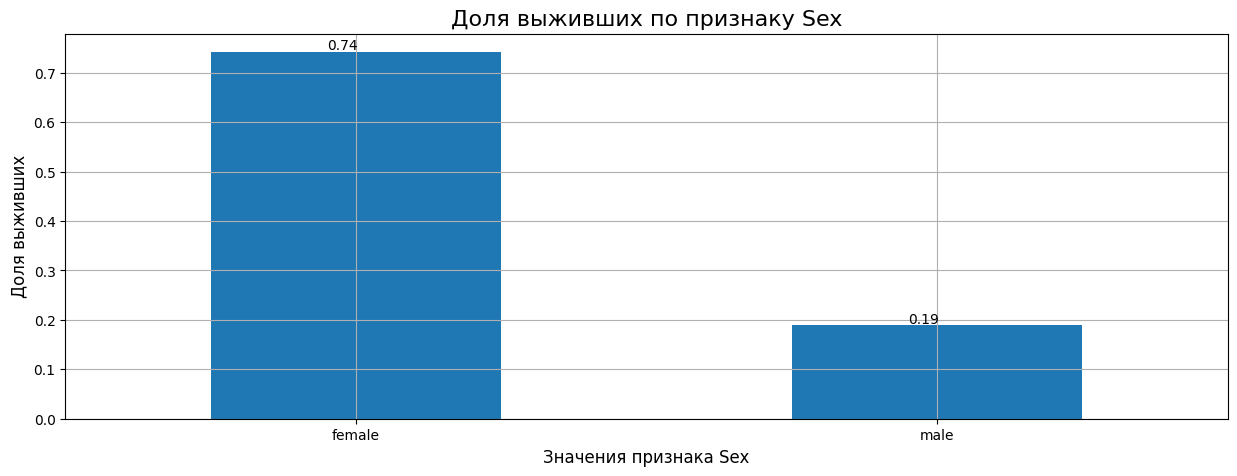

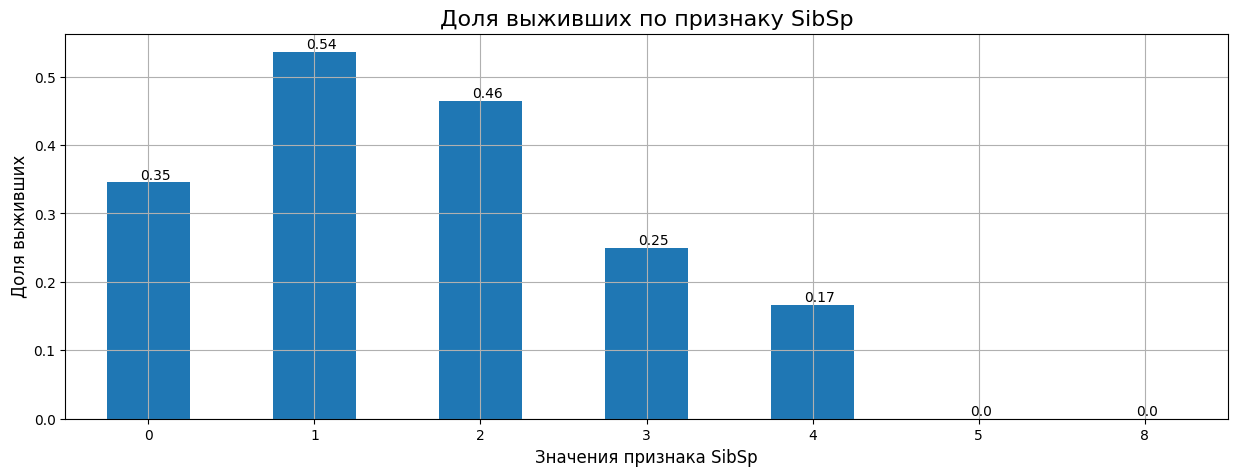

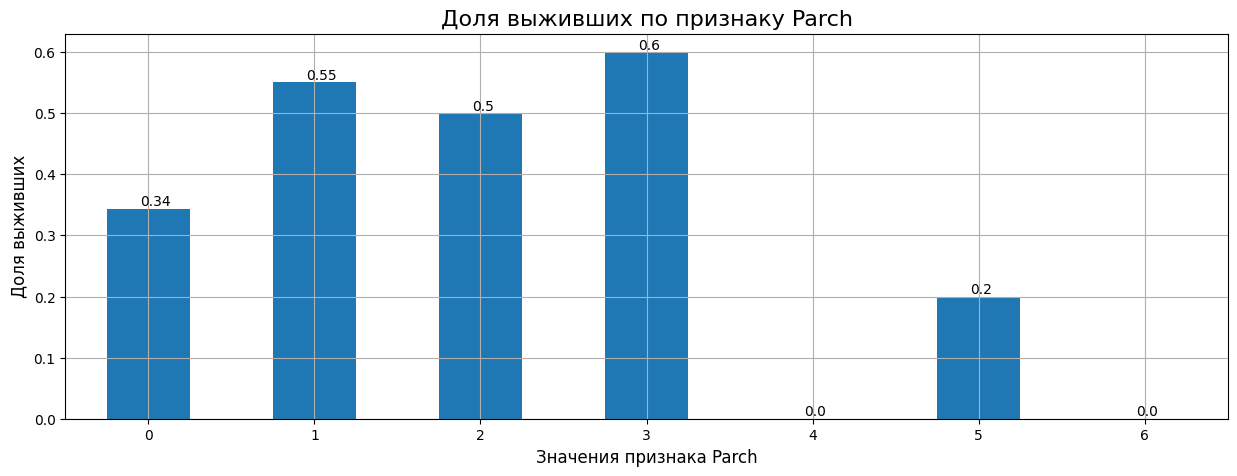

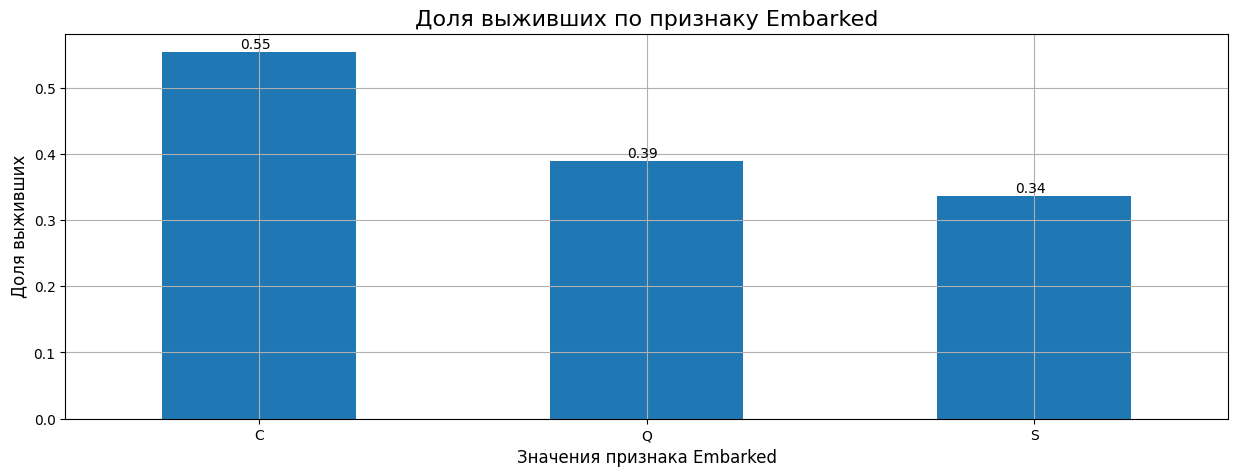

In [294]:
columns_to_look = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

for column in columns_to_look:
    pivot = training_set.pivot_table(index=column, values='Survived', aggfunc='mean')
    
    fig, ax = plt.subplots(figsize=(15,5))
    ax.set_title(f'Доля выживших по признаку {column}', fontdict={'size': 16})
    ax.set_ylabel('Доля выживших', fontdict={'size': 12})
    ax.set_xlabel(column, fontdict={'size': 12})
    
    for cnt in range(pivot.shape[0]):
        value = pivot.iloc[cnt].values[0]
        ax.text(cnt - .05, value + .005, round(value, 2))
        
    pivot.plot(kind='bar', rot=0, grid=True, legend=False, ax=ax) 
    ax.set_xlabel(f'Значения признака {column}', fontdict={'size': 12})
    plt.show()

In [295]:
training_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [296]:
training_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [297]:
training_set.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [298]:
training_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


<Axes: >

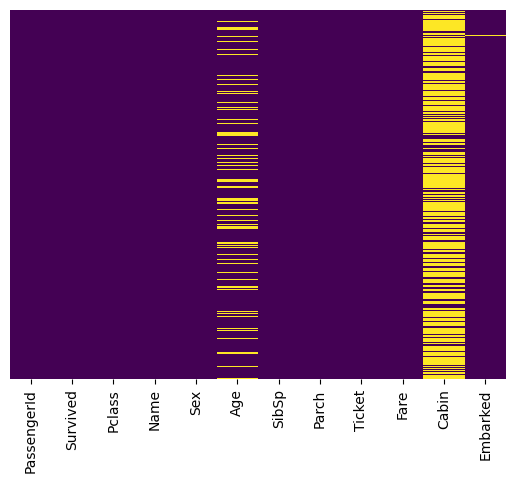

In [299]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

<Axes: >

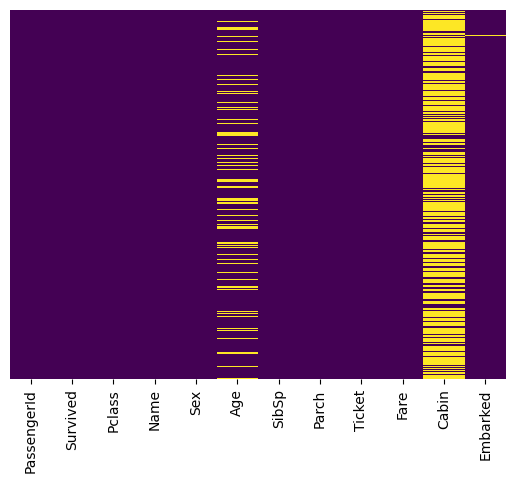

In [300]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [301]:
training_set.drop('Cabin', axis=1, inplace=True)
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: >

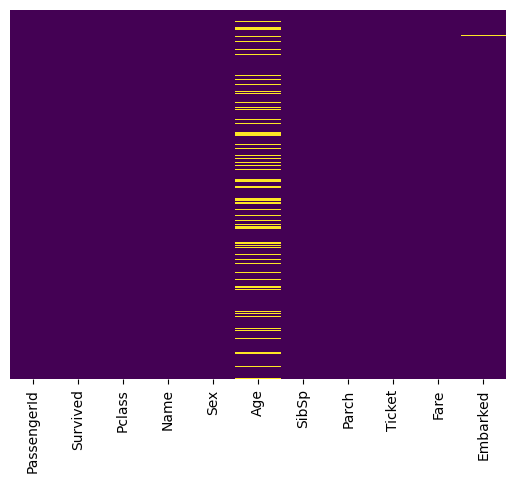

In [302]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [303]:
training_set.dropna(inplace=True)
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [304]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

le = LabelEncoder()
cat_enc_le = le.fit_transform(training_set['Sex'])

training_set['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [305]:
np.unique(cat_enc_le)  

array([0, 1])

In [306]:
le.inverse_transform([0,1])

array(['female', 'male'], dtype=object)

In [307]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(training_set[['Embarked']])

training_set.shape

(712, 11)

In [308]:
cat_enc_ohe.shape

(712, 3)

In [309]:
pd.get_dummies(training_set['Sex'])

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
885,True,False
886,False,True
887,True,False
889,False,True


In [310]:
pd.get_dummies(training_set['Sex'], drop_first=True)

,male
0,True
1,False
2,False
3,False
4,True
...,...
885,False
886,True
887,False
889,True


In [311]:
sex = pd.get_dummies(training_set['Sex'], drop_first=True)
embark = pd.get_dummies(training_set['Embarked'], drop_first=True)
embark.head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [312]:
training_set = pd.concat([training_set, sex, embark], axis=1)
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,False,True


In [313]:
training_set.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)
training_set.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## Задания для самостоятельного выполнения

#### 1. Постройте по получившемуся набору данных простую модель машинного обучения и оцените ее эффективность.

Accuracy: 0.797
F1-score: 0.743


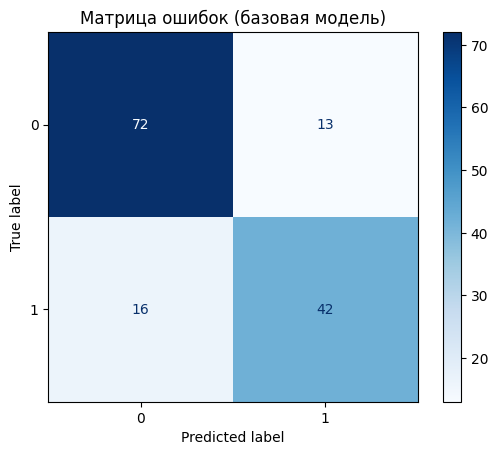

In [314]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

raw_df = pd.read_csv('data/titanic.csv')
clean_df = raw_df.drop(columns=['Cabin']).dropna().copy()
clean_df = pd.get_dummies(clean_df, columns=['Sex', 'Embarked'], drop_first=True)
clean_df = clean_df.drop(columns=['Name', 'Ticket', 'PassengerId'])

X = clean_df.drop(columns=['Survived'])
y = clean_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'F1-score: {f1_score(y_test, y_pred):.3f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Матрица ошибок (базовая модель)')
plt.show()

# базовая модель логистической регрессии работает удовлетворительно

#### 2. Ответьте на следующие вопросы при помощи визуализации и численных данных по исходному набору данных:

#### 3. Какова доля выживших после крушения пассажиров? Какова доля мужчин и женщин среди выживших?

In [315]:
survival_rate = raw_df['Survived'].mean()
survivors_gender_share = (
    raw_df[raw_df['Survived'] == 1]['Sex']
    .value_counts(normalize=True)
    .rename('Доля среди выживших')
    .to_frame()
    .round(3)
 )

print(f'Доля выживших: {survival_rate:.3f} ({survival_rate*100:.1f}%)')
display(survivors_gender_share)

Доля выживших: 0.384 (38.4%)


,Доля среди выживших
Sex,
female,0.681
male,0.319


#### 4. Сколько пассажиров ехало в каждом классе? Кого было больше в самом многолюдном классе — мужчин или женщин?

Пассажиров в каждом классе:


,Количество
Pclass,
1,216
2,184
3,491


Самый многолюдный класс: 3
В нём больше: мужчин


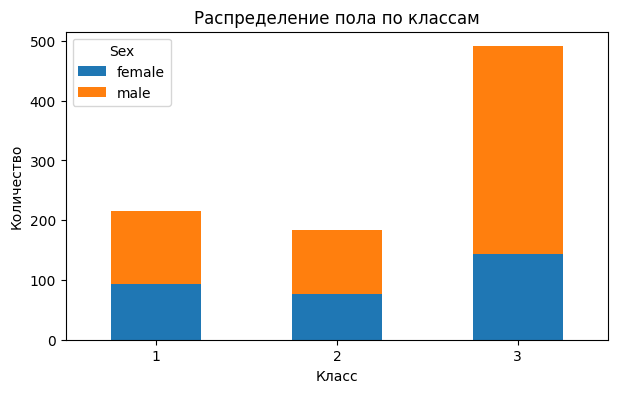

In [316]:
class_counts = raw_df['Pclass'].value_counts().sort_index().rename('Количество')
class_sex = pd.crosstab(raw_df['Pclass'], raw_df['Sex'])

print('Пассажиров в каждом классе:')
display(class_counts.to_frame())

busiest_class = class_counts.idxmax()
sex_in_busiest = class_sex.loc[busiest_class]
print(f'Самый многолюдный класс: {busiest_class}')
print('В нём больше:', 'мужчин' if sex_in_busiest['male'] > sex_in_busiest['female'] else 'женщин')

class_sex.plot(kind='bar', stacked=True, figsize=(7,4))
plt.title('Распределение пола по классам')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

#### 5. Все ли признаки несут в себе полезную информацию? Почему? Избавьтесь от ненужных столбцов.

In [317]:
feature_info = pd.DataFrame({
    'missing_%': (raw_df.isna().mean() * 100).round(1),
    'unique': raw_df.nunique()
}).sort_values('missing_%', ascending=False)

display(feature_info)

reduced_df = raw_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
print('Размер после удаления ненужных столбцов:', reduced_df.shape)

# наименее полезные для простой модели столбцы: PassengerId, Name, Ticket, Cabin

,missing_%,unique
Cabin,77.1,147
Age,19.9,88
Embarked,0.2,3
PassengerId,0.0,891
Name,0.0,891
Pclass,0.0,3
Survived,0.0,2
Sex,0.0,2
Parch,0.0,7
SibSp,0.0,7


Размер после удаления ненужных столбцов: (891, 8)


#### 6. Посчитайте, насколько сильно коррелируют друг с другом цена за билет и возраст пассажиров. Также проверьте наличие этой зависимости визуально (в этом вам поможет построение диаграммы рассеяния).

Корреляция Age-Fare: 0.096


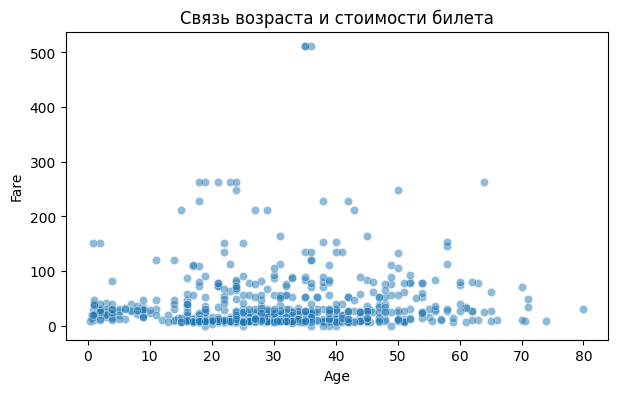

In [318]:
tmp = raw_df[['Age', 'Fare']].dropna().copy()
corr = tmp['Age'].corr(tmp['Fare'])
print(f'Корреляция Age-Fare: {corr:.3f}')

plt.figure(figsize=(7,4))
sns.scatterplot(data=tmp, x='Age', y='Fare', alpha=0.5)
plt.title('Связь возраста и стоимости билета')
plt.show()

#связь слабая (по модулю ближе к 0, чем к 1)

#### 7. Правда ли, что чаще выживали пассажиры с более дорогими билетами? А есть ли зависимость выживаемости от класса?

In [319]:
tmp = raw_df[['Survived', 'Fare', 'Pclass']].dropna().copy()
tmp['fare_bin'] = pd.qcut(tmp['Fare'], q=4, duplicates='drop')

surv_by_fare = tmp.groupby('fare_bin', observed=False)['Survived'].mean().round(3)
surv_by_class = tmp.groupby('Pclass')['Survived'].mean().round(3)

print('Доля выживших по квартилям цены билета:')
display(surv_by_fare.to_frame('Survival rate'))
print('Доля выживших по классам:')
display(surv_by_class.to_frame('Survival rate'))

# выживаемость выше при более дорогих билетах и в более высоком классе

Доля выживших по квартилям цены билета:


,Survival rate
fare_bin,
"(-0.001, 7.91]",0.197
"(7.91, 14.454]",0.304
"(14.454, 31.0]",0.455
"(31.0, 512.329]",0.581


Доля выживших по классам:


,Survival rate
Pclass,
1,0.630
2,0.473
3,0.242


#### 8. Какова связь между стоимостью билета и портом отправления? Выведите минимальную, среднюю и максимальную сумму, которую заплатили пассажиры за проезд. Проделайте то же самое только для тех пассажиров, которые сели на корабль в Саутгемптоне.

In [320]:
fare_stats_all = raw_df['Fare'].agg(['min', 'mean', 'max']).round(2).to_frame('Все пассажиры')
fare_stats_s = raw_df[raw_df['Embarked'] == 'S']['Fare'].agg(['min', 'mean', 'max']).round(2).to_frame('Только Southampton (S)')

print('Статистика стоимости билета (минимум, среднее, максимум):')
display(pd.concat([fare_stats_all, fare_stats_s], axis=1))

Статистика стоимости билета (минимум, среднее, максимум):


,Все пассажиры,Только Southampton (S)
min,0.00,0.00
mean,32.20,27.08
max,512.33,263.00


Только для пассажиров из Саутгемптона:


,Southampton (S)
min,0.00
mean,27.08
max,263.00


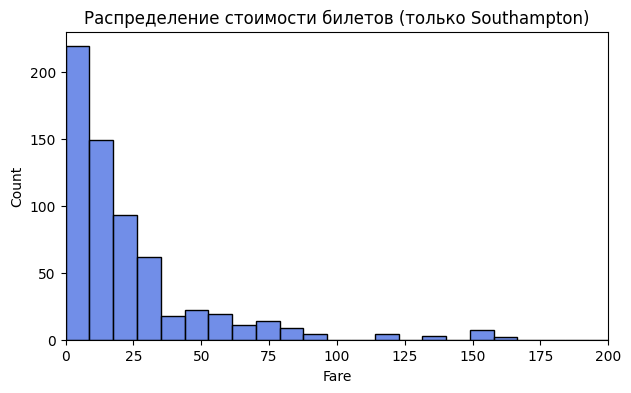

In [321]:
southampton_df = raw_df[raw_df['Embarked'] == 'S'].copy()

southampton_stats = southampton_df['Fare'].agg(['min', 'mean', 'max']).round(2).to_frame('Southampton (S)')
print('Только для пассажиров из Саутгемптона:')
display(southampton_stats)

plt.figure(figsize=(7,4))
sns.histplot(southampton_df['Fare'], bins=30, color='royalblue')
plt.title('Распределение стоимости билетов (только Southampton)')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.xlim(0, 200)
plt.show()

#### 9. Выведите гистограммы, показывающие распределения стоимостей билетов в зависимости от места посадки.

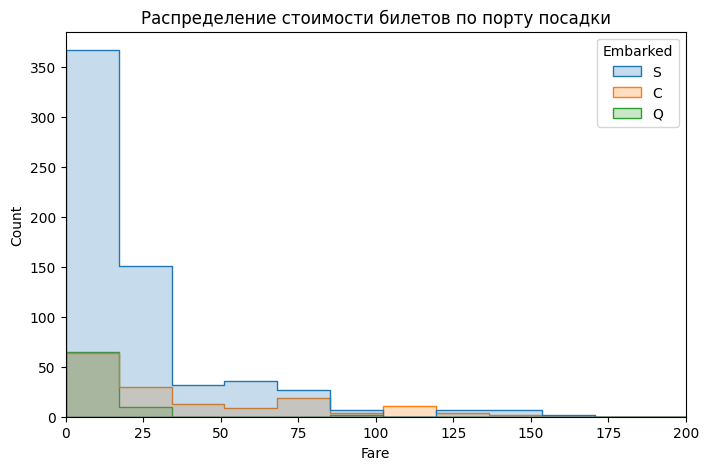

In [322]:
plt.figure(figsize=(8,5))
sns.histplot(data=raw_df, x='Fare', hue='Embarked', bins=30, element='step', common_norm=False)
plt.title('Распределение стоимости билетов по порту посадки')
plt.xlim(0, 200)
plt.show()

# распределения различаются, особенно по доле более дорогих билетов

#### 10. Оцените репрезентативность представленной выборки. Сколько всего было пассажиров Титаника? Сколько из них выжило? Какую долю составляет представленный набор данных от всей генеральной совокупности?

In [323]:
total_population = 2224
total_survivors_population = 710

sample_size = len(raw_df)
sample_survivors = int(raw_df['Survived'].sum())

summary = pd.DataFrame({
    'Показатель': ['Всего пассажиров', 'Выживших', 'Доля выживших'],
    'Генеральная совокупность': [total_population, total_survivors_population, round(total_survivors_population / total_population, 3)],
    'Набор данных': [sample_size, sample_survivors, round(sample_survivors / sample_size, 3)]
})

display(summary)
print(f'Доля выборки от всей совокупности: {sample_size / total_population:.3f} ({sample_size / total_population * 100:.1f}%)')

#выборка крупная, но не полная; репрезентативность подойдет для учебного анализа

,Показатель,Генеральная совокупность,Набор данных
0,Всего пассажиров,2224.000,891.000
1,Выживших,710.000,342.000
2,Доля выживших,0.319,0.384


Доля выборки от всей совокупности: 0.401 (40.1%)


#### 11. Разделите выборку на тестовую и обучающую части при помощи train_test_split(). Изобразите на графиках распределение некоторых атрибутов и целевой переменной. Насколько однородно получившееся разбиение?

Сравнение train/test:


,Train,Test
Survived rate,0.404,0.406
Mean Age,29.472,30.317
Mean Fare,32.741,41.833


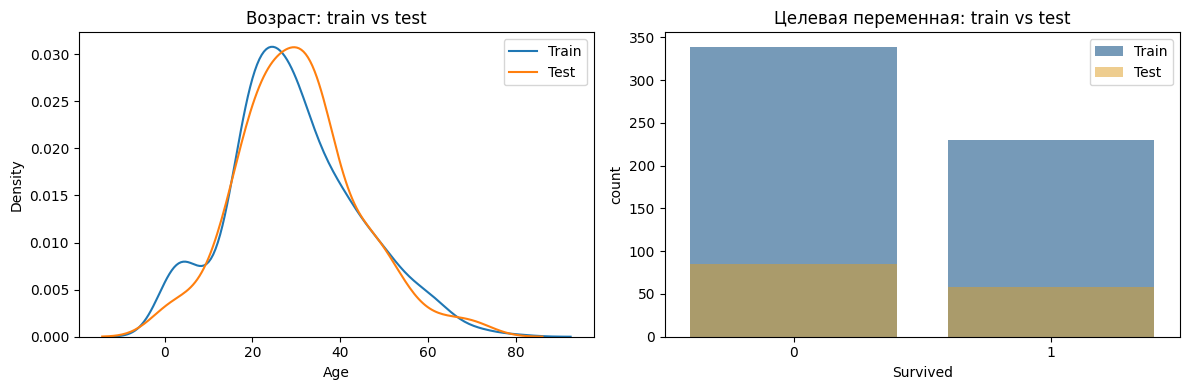

In [ ]:
from sklearn.model_selection import train_test_split

if 'clean_df' not in globals():
    clean_df = raw_df.drop(columns=['Cabin']).dropna().copy()

train_df, test_df = train_test_split(
    clean_df, test_size=0.2, random_state=42, stratify=clean_df['Survived']
 )

comp = pd.DataFrame({
    'Train': [train_df['Survived'].mean(), train_df['Age'].mean(), train_df['Fare'].mean()],
    'Test': [test_df['Survived'].mean(), test_df['Age'].mean(), test_df['Fare'].mean()]
}, index=['Survived rate', 'Mean Age', 'Mean Fare']).round(3)

print('Сравнение train/test:')
display(comp)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.kdeplot(train_df['Age'], label='Train', ax=axes[0])
sns.kdeplot(test_df['Age'], label='Test', ax=axes[0])
axes[0].set_title('Возраст: train vs test')
axes[0].legend()

sns.countplot(x='Survived', data=train_df, ax=axes[1], color='steelblue', alpha=0.8, label='Train')
sns.countplot(x='Survived', data=test_df, ax=axes[1], color='orange', alpha=0.5, label='Test')
axes[1].set_title('Целевая переменная: train vs test')
axes[1].legend()
plt.tight_layout()
plt.show()

# разбиение достаточно однородное

#### 12. Сбалансируйте классы в исходном датасете двумя способами:

#### 13. Удалите лишние объекты мажоритарного класса (выбранные случайно)

In [325]:
if 'clean_df' not in globals():
    clean_df = raw_df.drop(columns=['Cabin']).dropna().copy()

majority = clean_df[clean_df['Survived'] == 0]
minority = clean_df[clean_df['Survived'] == 1]

majority_down = majority.sample(n=len(minority), random_state=42)
balanced_under = pd.concat([majority_down, minority]).sample(frac=1, random_state=42)

counts_under = balanced_under['Survived'].value_counts().sort_index()
print('Размеры классов после undersampling:')
display(counts_under.to_frame('count'))

Размеры классов после undersampling:


,count
Survived,
0,288
1,288


#### 14. Добавьте в выборку дубликаты миноритарного класса.

In [326]:
if 'clean_df' not in globals():
    clean_df = raw_df.drop(columns=['Cabin']).dropna().copy()

majority = clean_df[clean_df['Survived'] == 0]
minority = clean_df[clean_df['Survived'] == 1]

minority_up = minority.sample(n=len(majority), replace=True, random_state=42)
balanced_over = pd.concat([majority, minority_up]).sample(frac=1, random_state=42)

counts_over = balanced_over['Survived'].value_counts().sort_index()
print('Размеры классов после oversampling:')
display(counts_over.to_frame('count'))

Размеры классов после oversampling:


,count
Survived,
0,424
1,424


#### 15. Проведите исследование эффективности простой модели классификации до и после данных преобразований.

In [327]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

base_df = raw_df.drop(columns=['Cabin']).dropna().copy()

majority = base_df[base_df['Survived'] == 0]
minority = base_df[base_df['Survived'] == 1]
majority_down = majority.sample(n=len(minority), random_state=42)
balanced_under = pd.concat([majority_down, minority]).sample(frac=1, random_state=42)
minority_up = minority.sample(n=len(majority), replace=True, random_state=42)
balanced_over = pd.concat([majority, minority_up]).sample(frac=1, random_state=42)

def eval_simple(df, name):
    df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
    X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])
    y = df['Survived']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        'dataset': name,
        'accuracy': round(accuracy_score(y_test, pred), 3),
        'f1': round(f1_score(y_test, pred), 3)
    }

res = pd.DataFrame([
    eval_simple(base_df.copy(), 'Исходный'),
    eval_simple(balanced_under.copy(), 'После undersampling'),
    eval_simple(balanced_over.copy(), 'После oversampling')
])
display(res)
# балансировка обычно повышает F1 по миноритарному классу ценой небольшой потери общей точности

,dataset,accuracy,f1
0,Исходный,0.797,0.743
1,После undersampling,0.819,0.817
2,После oversampling,0.741,0.725


#### 16. Постройте корреляционную матрицу признаков после преобразования данных. Сделайте вывод о наличии либо отсутствии мультиколлинеарности признаков.

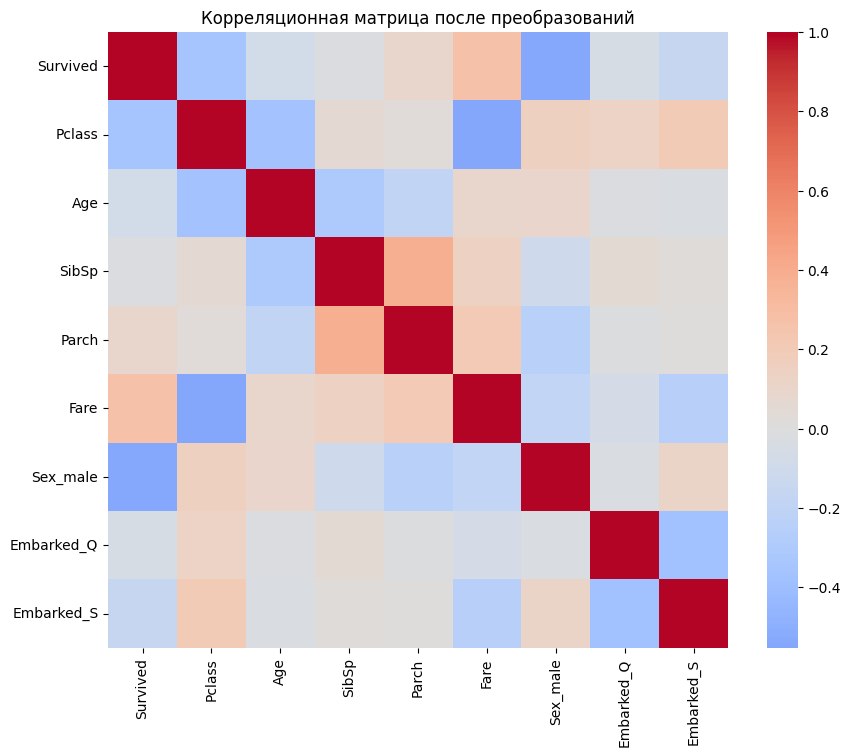

Сильные корреляции (|corr| > 0.8):


,Комментарий
0,нет сильной мультиколлинеарности


In [328]:
base_df = raw_df.drop(columns=['Cabin']).dropna().copy()
corr_input = base_df.drop(columns=['Name', 'Ticket', 'PassengerId'])
corr_df = pd.get_dummies(corr_input, drop_first=True)
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица после преобразований')
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
 )
high_corr = high_corr[high_corr['corr'].abs() > 0.8].sort_values('corr', key=np.abs, ascending=False)

print('Сильные корреляции (|corr| > 0.8):')
display(high_corr if len(high_corr) else pd.DataFrame({'Комментарий': ['нет сильной мультиколлинеарности']}))

#### 17. Проведите группировку данных по значению возраста. Введите новый признак "возрастная категория", значениями которой будут "ребенок", "взрослый", "старик". Проведите анализ эффективности данного признака.

,Количество,Доля выживших
age_category,,
ребенок,113,0.540
взрослый,575,0.386
старик,26,0.269


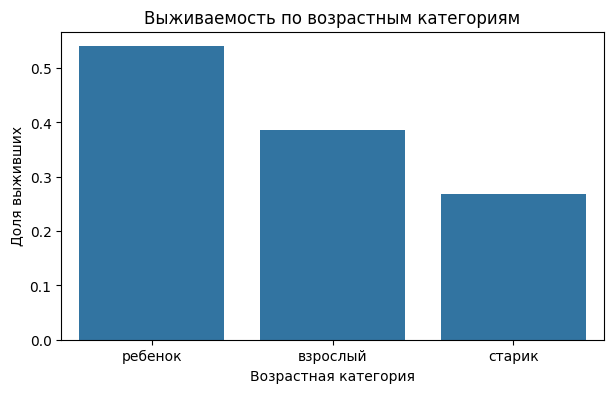

In [ ]:
age_df = raw_df[['Age', 'Survived']].dropna().copy()
age_df['age_category'] = pd.cut(
    age_df['Age'],
    bins=[0, 18, 60, 120],
    labels=['ребенок', 'взрослый', 'старик'],
    right=False
 )

age_stats = age_df.groupby('age_category', observed=False)['Survived'].agg(['count', 'mean']).round(3)
age_stats = age_stats.rename(columns={'count': 'Количество', 'mean': 'Доля выживших'})
display(age_stats)

plt.figure(figsize=(7,4))
sns.barplot(x=age_stats.index, y=age_stats['Доля выживших'])
plt.title('Выживаемость по возрастным категориям')
plt.xlabel('Возрастная категория')
plt.ylabel('Доля выживших')
plt.show()

# возрастная категория может быть полезным дополнительным признаком